In [60]:
!export UNIBENCH_HUB=/storage/home/hcoda1/6/haltahan6/p-rmurty7-0/haider/.cache/unibench
# %load_ext cudf.pandas
import pandas as pd

# from eval_vlm.datasets_zoo.registry import list_datasets
from unibench.common_utils.utils import list_models
from unibench.output import OutputHandler
import seaborn as sns
import matplotlib.pyplot as plt

models = [
    "paligemma_3b_224",
    "paligemma_3b_mix_224",
    "paligemma_3b_448",
    "paligemma_3b_mix_448",
    "paligemma2_3b_mix_224",
    "paligemma2_3b_mix_448",
    "llava_1_5_7b",
    "bakllava_1_7b",
    "chameleon_7b",
    "llava_next_vicuna_7b",
    "paligemma2_10b_mix_224",
    "paligemma2_10b_mix_448",
    "llama_3_2_11b",
    "llava_1_5_13b",
    "llava_next_vicuna_13b",
    "llava_next_llama_8b",
    "llava_next_mistral_7b",
    "paligemma2_28b_mix_224",
    "paligemma2_28b_mix_448",
    "clip_vitB32"
    # "cambrian_8b",
    # "chameleon_30b", need a fix
    # "llava_1_6_34b",
    # "llama_4_scout",
    # "llava_next_110b", not enough memory
]
outputhandler = OutputHandler(output_dir="/storage/home/hcoda1/6/haltahan6/p-rmurty7-0/haider/.cache/unibench/outputs", download_all_precomputed=True)
print(pd)

Fetching 8641 files: 100%|██████████| 8641/8641 [03:24<00:00, 42.30it/s]  

<module 'pandas' from '/storage/home/hcoda1/6/haltahan6/p-rmurty7-0/haider/anaconda3/envs/uni/lib/python3.9/site-packages/pandas/__init__.py'>


In [61]:
outputhandler.load_all_csvs(
    models,
)

Error reading file:  /storage/home/hcoda1/6/haltahan6/p-rmurty7-0/haider/.cache/unibench/outputs/llava_next_llama_8b/dollar_street.f
Error reading file:  /storage/home/hcoda1/6/haltahan6/p-rmurty7-0/haider/.cache/unibench/outputs/llava_next_mistral_7b/dollar_street.f


In [62]:
from unibench.common_utils import get_benchmark_mappings
results = outputhandler.query(**{"model_name": models})
dataset_mappings = get_benchmark_mappings("benchmark_type")
results["benchmark_type"] = results["benchmark_name"].map(dataset_mappings)

In [63]:
df_mean = results.groupby(["model_name", "benchmark_name"]).correctness.mean() * 100
df_sem = results.groupby(["model_name", "benchmark_name"]).correctness.sem()

/tmp/ipykernel_264612/44402579.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(


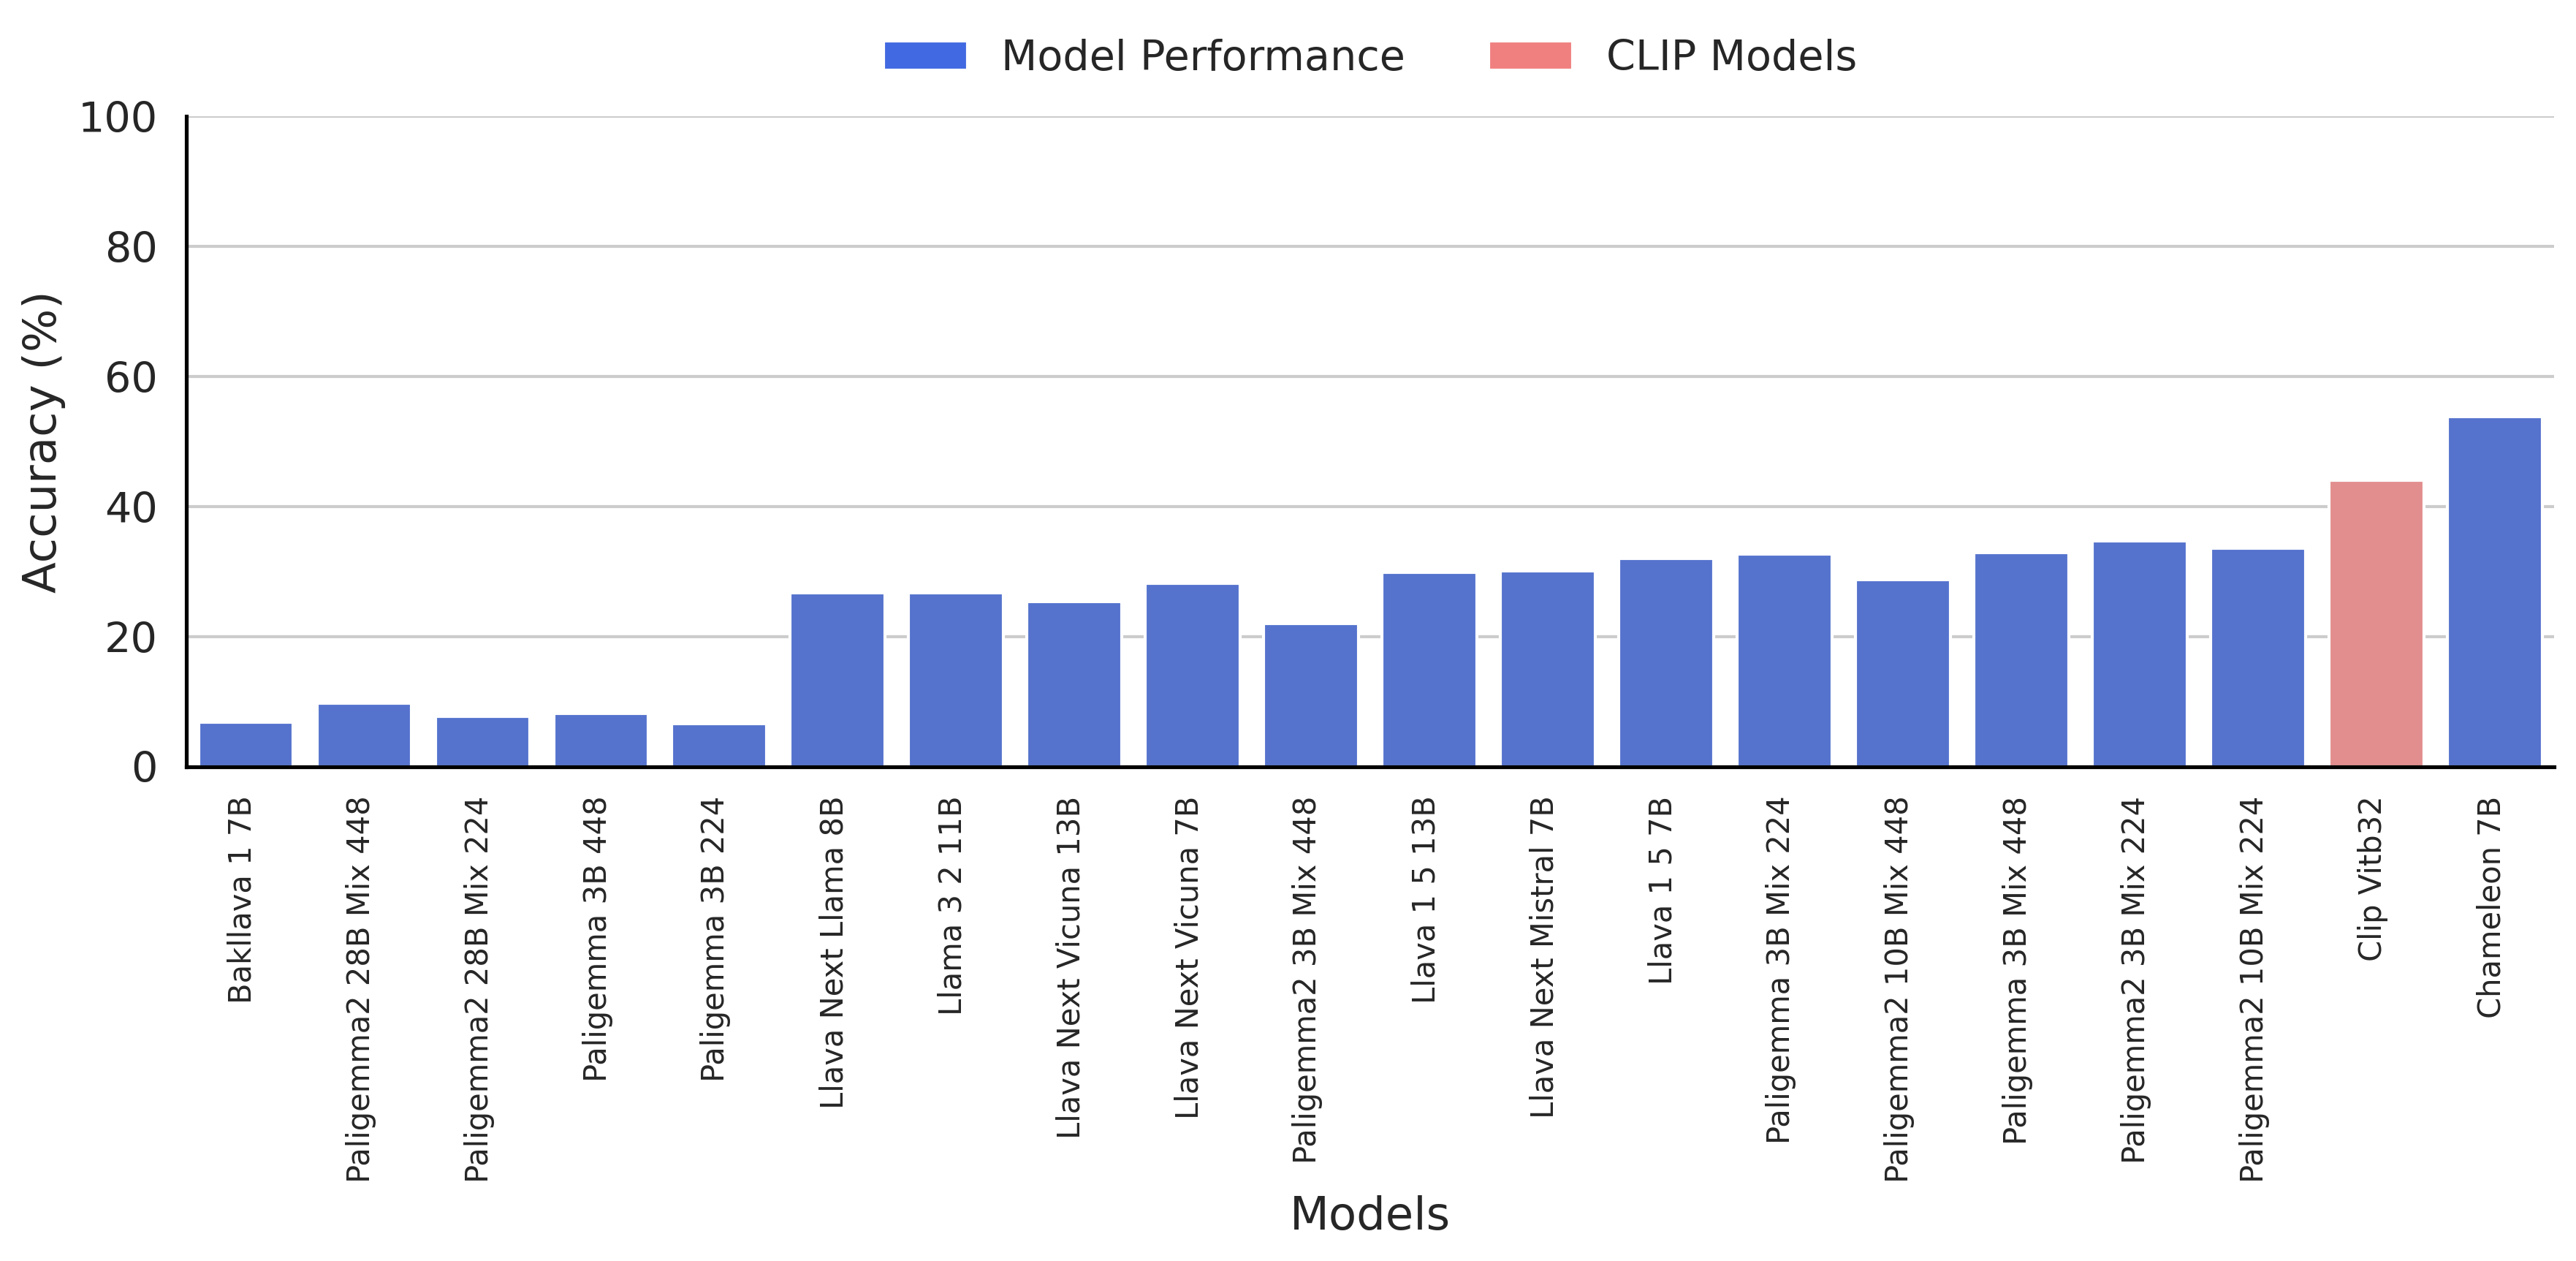

In [64]:
sns.set(font_scale=1.25)
sns.set_style("whitegrid")
fig, axs = plt.subplots(1, 1, sharex=True, sharey=True, figsize=(12, 6), dpi=300)

order = list(
    (
        df_mean.reset_index()
        .groupby("model_name")
        .correctness.median()
        .sort_values()
        .index
    )
)

m = df_mean.reset_index().groupby("model_name").correctness.mean() * 100
s = df_sem.reset_index().groupby("model_name").correctness.mean() * 100

sns.set_style(
    "whitegrid",
    rc={"ytick.left": True, "axes.grid": True},
)

# Create a color palette based on model names
colors = ["lightcoral" if "clip" in x.lower() else "royalblue" for x in order]

ax1 = sns.barplot(
    data=df_mean.reset_index(),
    x='model_name',
    y='correctness',
    palette=colors,
    errorbar=None,
    order=order,
    ax=axs,
)

for _, s in ax1.spines.items():
    s.set_color("black")

axs.set_ylim(0, 100)
sns.despine(ax=axs)

from matplotlib.patches import Patch

lgd = plt.legend(
    title=None,
    ncol=3,
    loc="lower center",
    bbox_to_anchor=(0.5, 1),
    handles=[
        Patch(
            facecolor="royalblue",
            label="Model Performance",
        ),
        Patch(
            facecolor="lightcoral", 
            label="CLIP Models",
        ),
    ],
    frameon=False,
)

axs.set_xticks(
    [x + 0.1 for x in axs.get_xticks()],
    [x.replace("_", " ").title() for x in order],
    rotation=90,
    ha="right",
)
axs.tick_params(axis="x", which="major", labelsize=10)

axs.set_xlabel("Models")
axs.set_ylabel("Accuracy (%)")
plt.tight_layout()
# plt.savefig("pngs/results_summary_mnist.png", dpi=300, bbox_inches="tight")


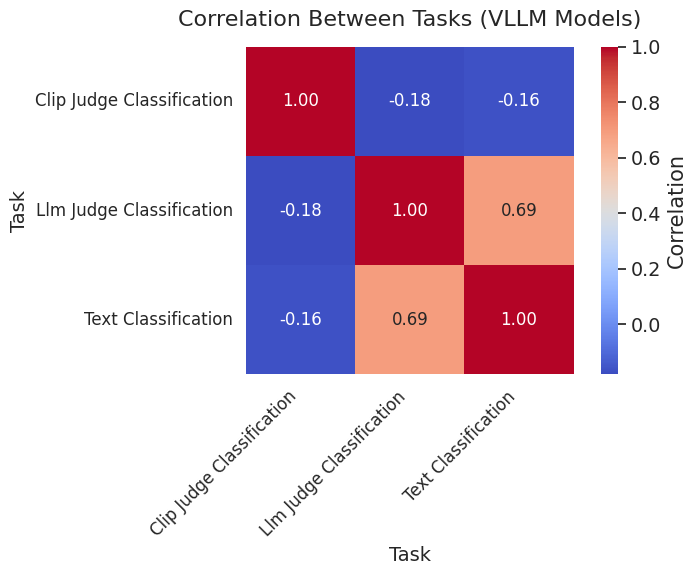

In [79]:
vllm_models = [
    "paligemma_3b_224",
    "paligemma_3b_mix_224",
    "paligemma_3b_448",
    "paligemma_3b_mix_448",
    "paligemma2_3b_mix_224",
    "paligemma2_3b_mix_448",
    "llava_1_5_7b",
    "bakllava_1_7b",
    "chameleon_7b",
    "llava_next_vicuna_7b",
    "paligemma2_10b_mix_224",
    "paligemma2_10b_mix_448",
    "llama_3_2_11b",
    "llava_1_5_13b",
    "llava_next_vicuna_13b",
    "llava_next_llama_8b",
    "llava_next_mistral_7b",
    "paligemma2_28b_mix_224",
    "paligemma2_28b_mix_448",
]

results_vllm = results[(results["model_name"].isin(vllm_models)) & (results.task_name != "relation_classification")]
# Pivot: rows=image_name, columns=task_name, values=mean correctness across models
pivot = (
    results_vllm.groupby(['benchmark_name', 'image_name', 'task_name'])['correctness']
    .mean()
    .unstack()
)

# Compute correlation matrix between tasks
corr = pivot.corr()

# Plot heatmap, clean axis labels for paper-ready figure
plt.figure(figsize=(8, 6))
ax = sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True,
    cbar_kws={"label": "Correlation"},
    annot_kws={"fontsize": 12}
)

# Clean x and y axis labels: remove underscores, use title case
clean_labels = [x.replace("_", " ").title() for x in corr.columns]
ax.set_xticklabels(clean_labels, rotation=45, ha="right", fontsize=12)
ax.set_yticklabels(clean_labels, rotation=0, fontsize=12)

ax.set_title("Correlation Between Tasks (VLLM Models)", fontsize=16, pad=15)
ax.set_xlabel("Task", fontsize=14)
ax.set_ylabel("Task", fontsize=14)
plt.tight_layout()
plt.show()
        


/tmp/ipykernel_264612/2120765829.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_task_perf.index, y=sorted_task_perf.values,
/tmp/ipykernel_264612/2120765829.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(clean_task_names, rotation=45)


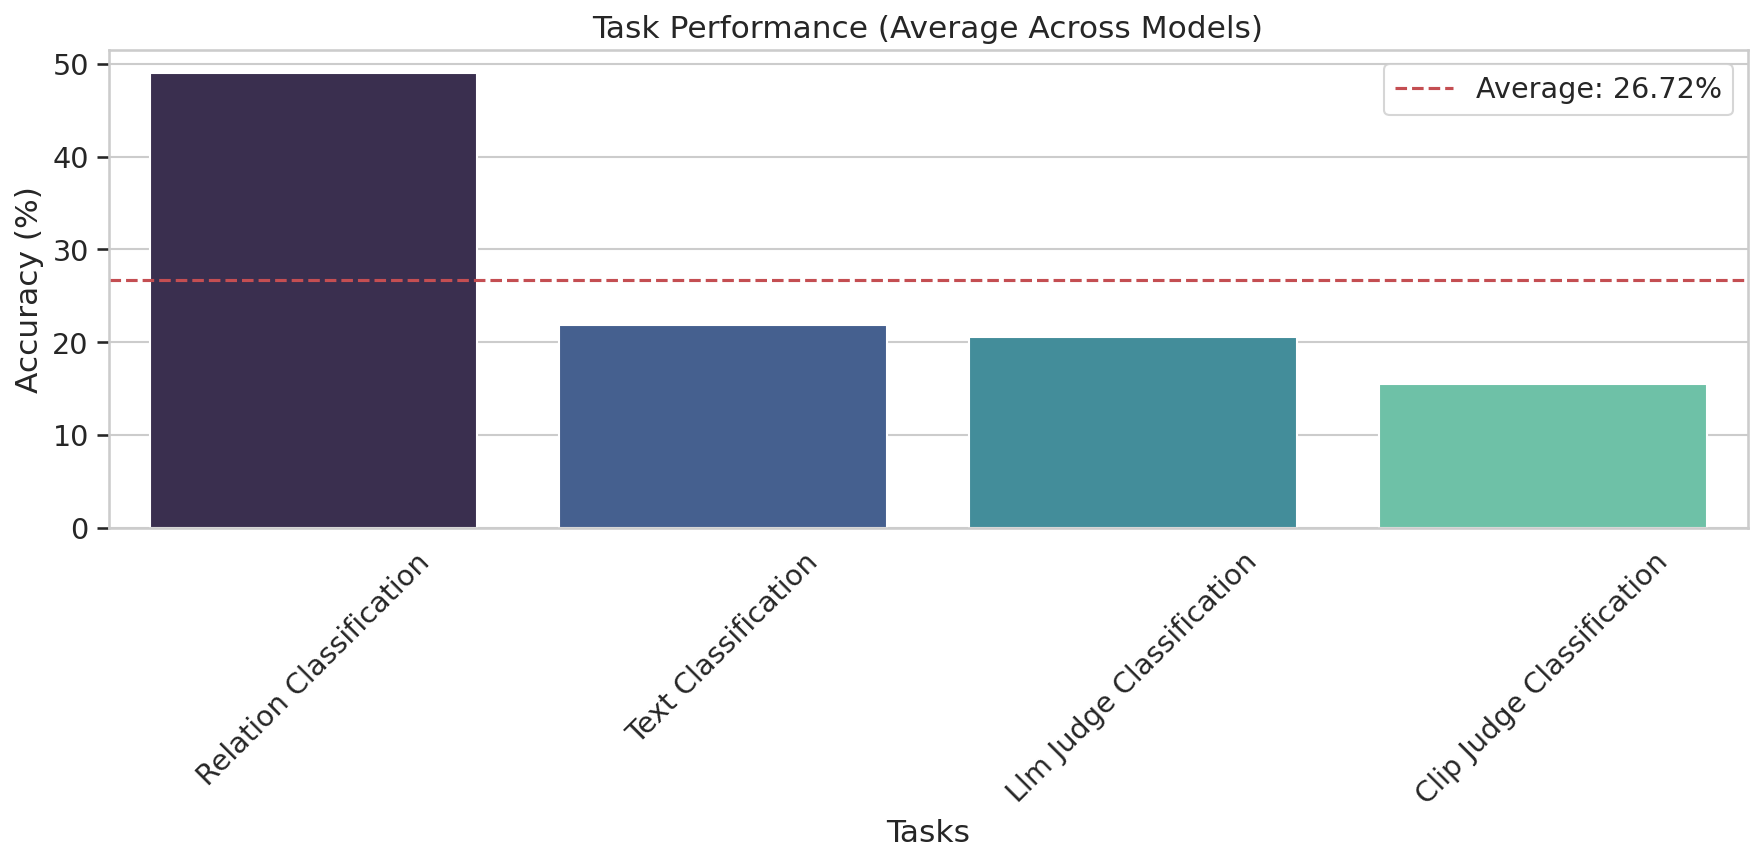

In [65]:
# First calculate model_mean_performance if not already defined
if 'model_mean_performance' not in locals():
    model_mean_performance = df_task_mean.groupby('model_name').correctness.mean() * 100

# Create a figure with only one plot for task performance
fig, ax = plt.subplots(figsize=(12, 6), dpi=150)

# Sort the task performance data
sorted_task_perf = task_mean_performance.sort_values(ascending=False)

# Clean task names for display
clean_task_names = [name.replace('_', ' ').title() for name in sorted_task_perf.index]

# Plot task performances
sns.barplot(x=sorted_task_perf.index, y=sorted_task_perf.values, 
            palette="mako", ax=ax)
ax.set_title('Task Performance (Average Across Models)', fontsize=15)
ax.set_ylabel('Accuracy (%)')
ax.set_xlabel('Tasks')
ax.axhline(y=task_mean_performance.mean(), color='r', linestyle='--', 
           label=f'Average: {task_mean_performance.mean():.2f}%')

# Set cleaned x-axis labels
ax.set_xticklabels(clean_task_names, rotation=45)
ax.legend()

plt.tight_layout()
plt.show()


/tmp/ipykernel_264612/1597205971.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(
/tmp/ipykernel_264612/1597205971.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(
/tmp/ipykernel_264612/1597205971.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(
/tmp/ipykernel_264612/1597205971.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(
/tmp/ipykernel_264612/15

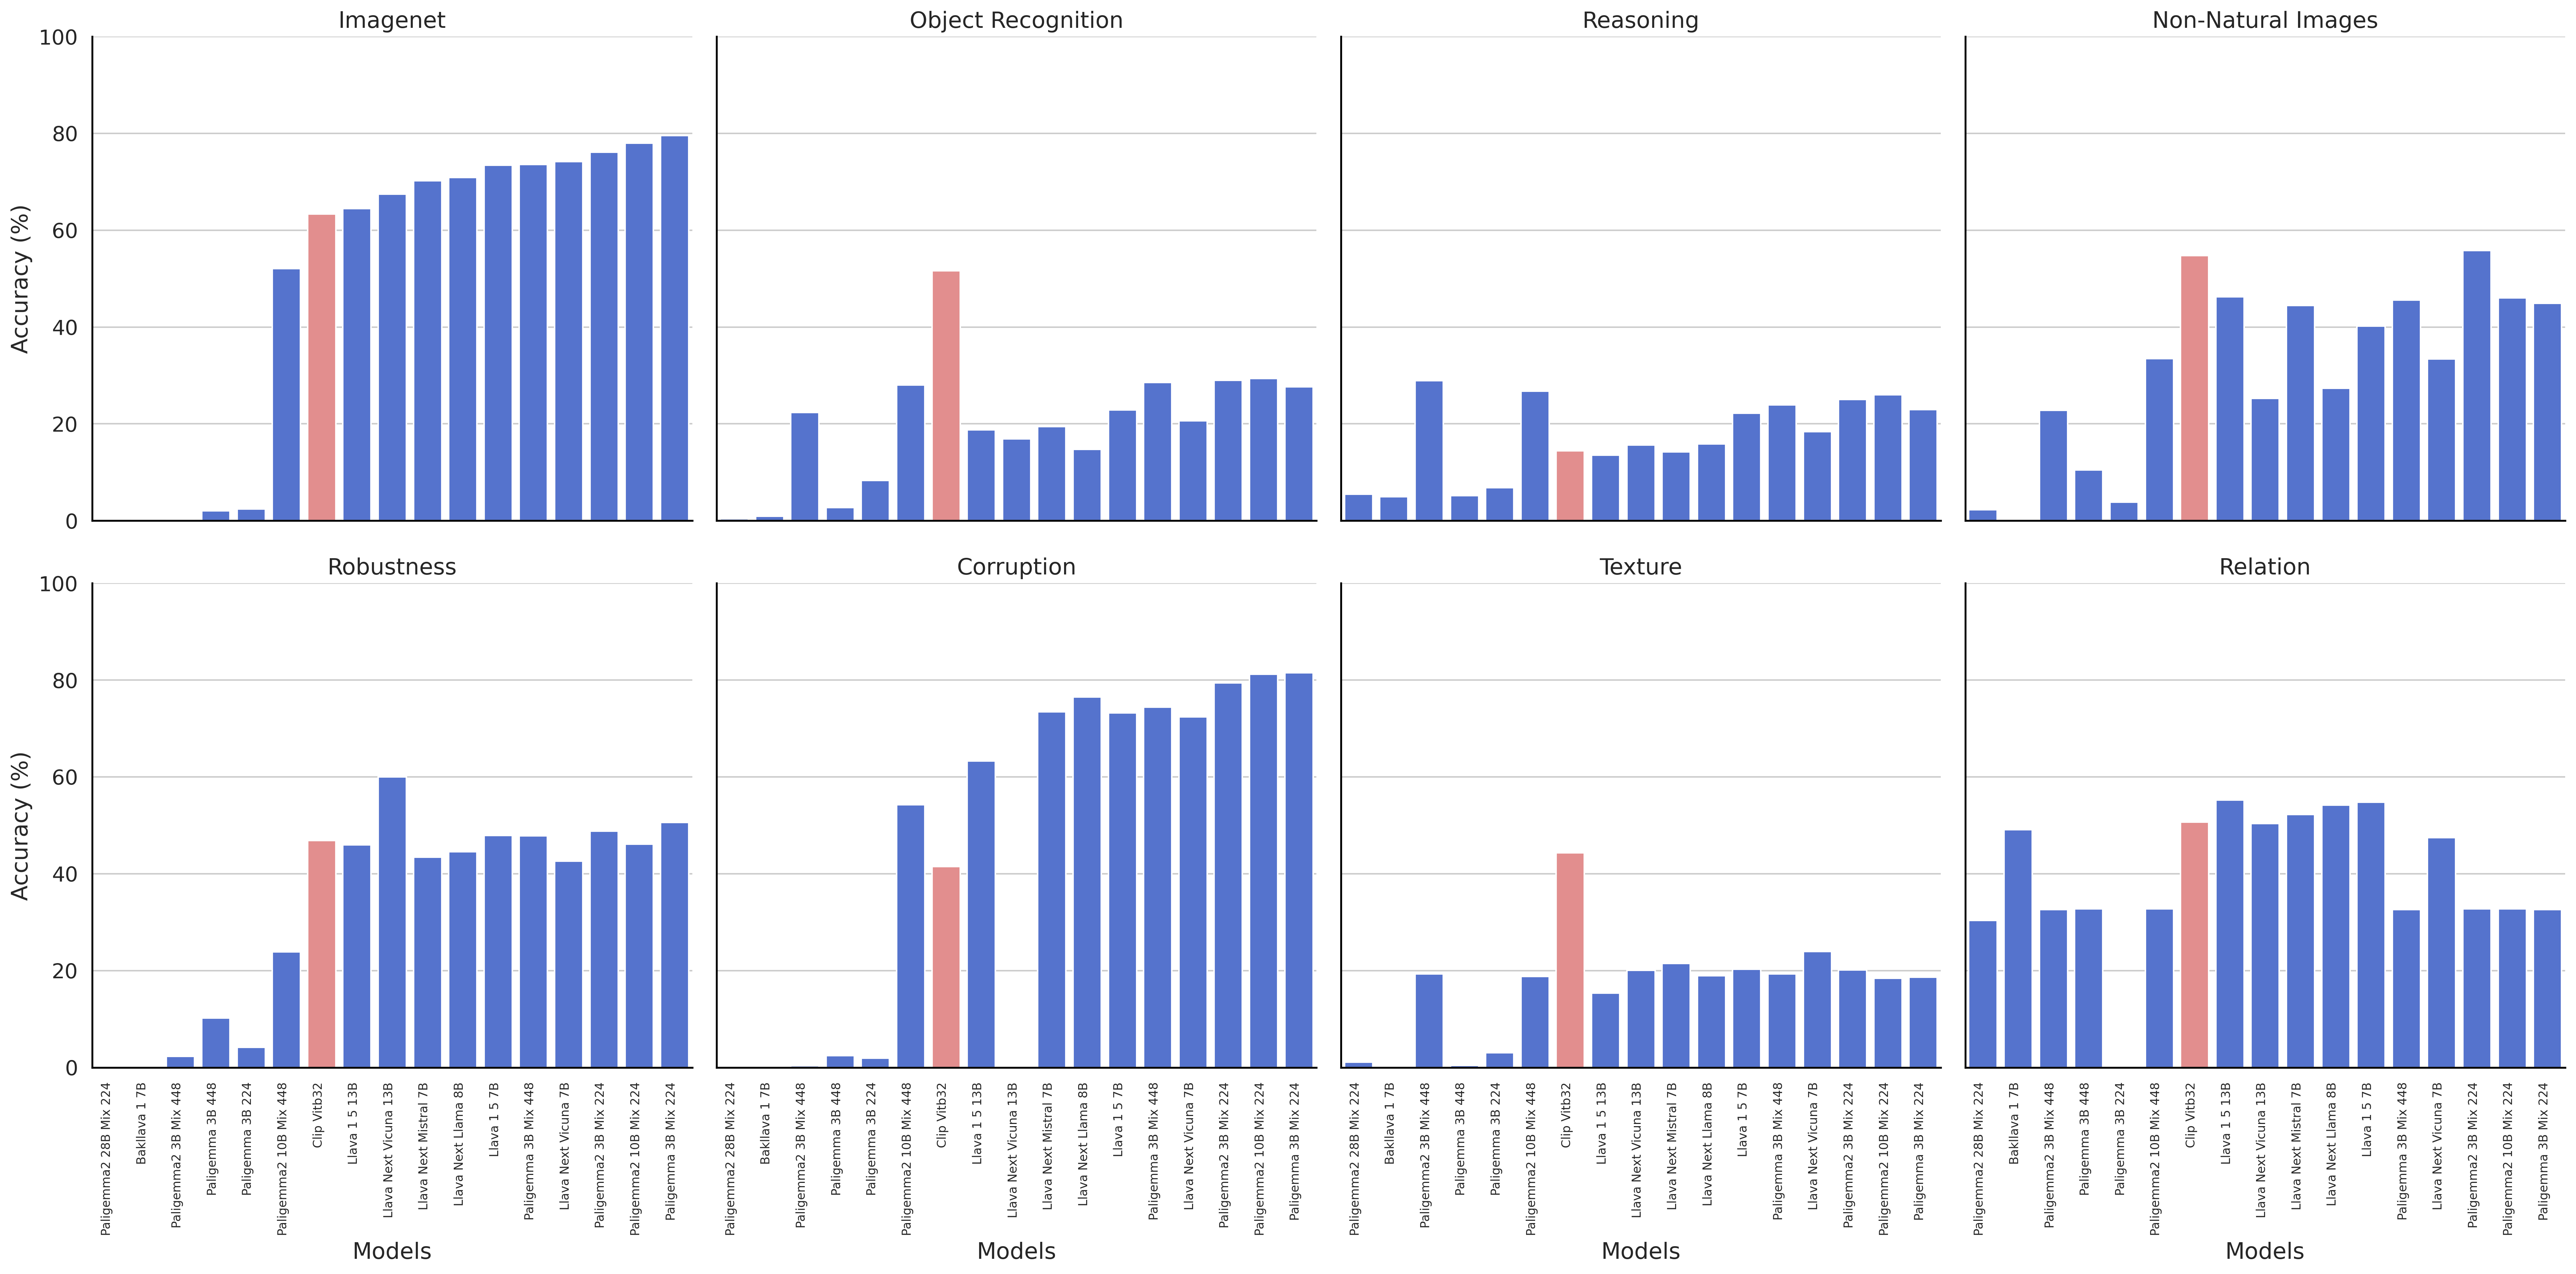

In [67]:
df_mean = (
    results.groupby(["model_name", "benchmark_name", "benchmark_type"])
    .correctness.mean()
    .reset_index()
)
df_sem = (
    results.groupby(["model_name", "benchmark_name", "benchmark_type"])
    .correctness.sem()
    .reset_index()
)

sns.set(font_scale=1.25)
sns.set_style("whitegrid")
fig, axs = plt.subplots(2, 4, sharex=True, sharey=True, figsize=(24, 12), dpi=300)

df_imagenet = df_mean[df_mean.benchmark_name == "imagenet1k"]

order = list(df_imagenet.groupby("model_name").correctness.mean().sort_values().index)
# order.append("2 Layer MLP")
benchmark_types = list(results.benchmark_type.unique())
benchmark_types.insert(0, "ImageNet")

sns.set_style(
    "whitegrid",
    rc={"ytick.left": True, "axes.grid": True},
)

for benchmark_type, ax in zip(benchmark_types, axs.flatten()):
    if benchmark_type == "ImageNet":
        m = df_imagenet
        s = df_sem[df_mean.benchmark_name == "imagenet1k"]
    else:
        m = df_mean[df_mean.benchmark_type == benchmark_type].reset_index()
        s = df_sem[df_mean.benchmark_type == benchmark_type].reset_index()

    m = m.reset_index().groupby("model_name").correctness.mean() * 100
    s = s.reset_index().groupby("model_name").correctness.mean() * 100

    ax1 = sns.barplot(
        x=list(m.keys()),
        y=list(m.values),
        palette=[
            "lightcoral" if "clip" in x.lower() else "royalblue"
            for x in order
        ],
        errorbar=None,
        order=order,
        ax=ax,
    )

    for _, s in ax1.spines.items():
        s.set_color("black")

    ax.set_ylim(0, 100)
    sns.despine(ax=ax)

    ax.set_xticks(
        [x + 0.01  for x in ax.get_xticks()],
        [x.replace("_", " ").title() for x in order],
        rotation=90,
        ha="right",
    )

    ax.set_title(benchmark_type.replace("_", " ").title())

    ax.tick_params(axis="x", which="major", labelsize=8)

    ax.set_xlabel("Models")
    ax.set_ylabel("Accuracy (%)")
plt.tight_layout()
plt.savefig("results_summary.pdf", dpi=300, bbox_inches="tight")